# Data Augmentation: Dogs vs Cats en PyTorch 

1. **Experimento A (sin data augmentation)**: entrenar una CNN pequeña y observar sobreajuste.
2. **Experimento B (con data augmentation)**: aplicar transformaciones aleatorias para retrasar sobreajuste y mejorar generalizacion.

Dataset objetivo:
- `cats_vs_dogs_small/train/{cat,dog}`
- `cats_vs_dogs_small/validation/{cat,dog}`
- `cats_vs_dogs_small/test/{cat,dog}`

La idea central es: augmentation **no crea informacion nueva**, pero expone al modelo a mas variaciones de los mismos ejemplos durante entrenamiento.

[Dataset](https://www.kaggle.com/datasets/pavelno/cats-vs-dogs-small)




In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
FORCE_GPU = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if FORCE_GPU and not torch.cuda.is_available():
    raise RuntimeError('No se detecto GPU CUDA. Desactiva FORCE_GPU o habilita CUDA en tu entorno.')

USE_CUDA = torch.cuda.is_available()
device = torch.device('cuda:0' if USE_CUDA else 'cpu')

if USE_CUDA:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')
    print('Device: CUDA')
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('Device: CPU')

Device: CUDA
GPU: NVIDIA RTX A2000 Laptop GPU


In [2]:
import shutil
from pathlib import Path

BATCH_SIZE = 32
NUM_WORKERS = 2 if USE_CUDA else 0
PIN_MEMORY = USE_CUDA
IMAGE_SIZE = 180
EPOCHS = 50

base_dir = Path('../data/cats_vs_dogs_small')
original_dir = Path('train')


def has_valid_split(root: Path) -> bool:
    required = [
        root / 'train' / 'cat', root / 'train' / 'dog',
        root / 'validation' / 'cat', root / 'validation' / 'dog',
        root / 'test' / 'cat', root / 'test' / 'dog',
    ]
    if not all(p.exists() for p in required):
        return False
    # Asegura que existan imagenes reales para evitar errores de ImageFolder.
    return all(len(list(p.glob('*.jpg'))) + len(list(p.glob('*.jpeg'))) + len(list(p.glob('*.png'))) > 0 for p in required)


def make_subset(subset_name, start_index, end_index):
    for category in ('cat', 'dog'):
        dst_dir = base_dir / subset_name / category
        dst_dir.mkdir(parents=True, exist_ok=True)
        for i in range(start_index, end_index):
            fname = f'{category}.{i}.jpg'
            src = original_dir / fname
            dst = dst_dir / fname
            if src.exists() and not dst.exists():
                shutil.copyfile(src, dst)


# Si existe train original de Kaggle y el dataset reducido no es valido, construirlo.
if original_dir.exists() and not has_valid_split(base_dir):
    make_subset('train', 0, 1000)
    make_subset('validation', 1000, 1500)
    make_subset('test', 1500, 2500)

if not has_valid_split(base_dir):
    raise FileNotFoundError(
        'cats_vs_dogs_small no es valido o esta incompleto. '\
        'Debe contener train/validation/test con subcarpetas cat y dog con imagenes.'
    )

print('Dataset listo en:', base_dir.resolve())
print('DataLoader -> workers:', NUM_WORKERS, '| pin_memory:', PIN_MEMORY)
for split in ['train', 'validation', 'test']:
    c = len(list((base_dir / split / 'cat').glob('*.jpg')))
    d = len(list((base_dir / split / 'dog').glob('*.jpg')))
    print(f'{split}: cat={c}, dog={d}')

FileNotFoundError: cats_vs_dogs_small no es valido o esta incompleto. Debe contener train/validation/test con subcarpetas cat y dog con imagenes.

In [ ]:
plain_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

print('Transformaciones experimento A (sin augmentation):')
print('1) Resize(180,180)')
print('2) ToTensor()')
print('3) Normalize(mean=0.5, std=0.5)')

Transformaciones experimento A (sin augmentation):
1) Resize(180,180)
2) ToTensor()
3) Normalize(mean=0.5, std=0.5)


In [ ]:
from PIL import Image

# Datasets y DataLoaders del experimento A (sin augmentation)
train_plain = datasets.ImageFolder(base_dir / 'train', transform=plain_transform)
val_dataset = datasets.ImageFolder(base_dir / 'validation', transform=plain_transform)
test_dataset = datasets.ImageFolder(base_dir / 'test', transform=plain_transform)

train_plain_loader = DataLoader(
    train_plain,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print('Clases:', train_plain.classes)
print('Train:', len(train_plain), '| Val:', len(val_dataset), '| Test:', len(test_dataset))


show_aug_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(36),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
])

Clases: ['cat', 'dog']
Train: 2000 | Val: 1000 | Test: 2000


Imagen fija: cats_vs_dogs_small\train\dog\445.jpg
Clase: dog
Visualizacion secuencial: inicia en la ORIGINAL y aplica el pipeline completo en orden.

Transformaciones Experimento A (sin augmentation):
  1. Resize(size=(180, 180), interpolation=bilinear, max_size=None, antialias=True)
  2. ToTensor()
  3. Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))

Transformaciones usadas para visualizacion:
  1. Resize(size=(180, 180), interpolation=bilinear, max_size=None, antialias=True)
  2. RandomHorizontalFlip(p=0.5)
  3. RandomRotation(degrees=[-36.0, 36.0], interpolation=nearest, expand=False, fill=0)
  4. RandomResizedCrop(size=(180, 180), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
  5. ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
  6. ToTensor()

Pipeline completo de augmentation (train):
  1. Resize(size=(180, 180), interpolation=bilinear, max_size=None, antialias=True)
  2. RandomHorizontalFli

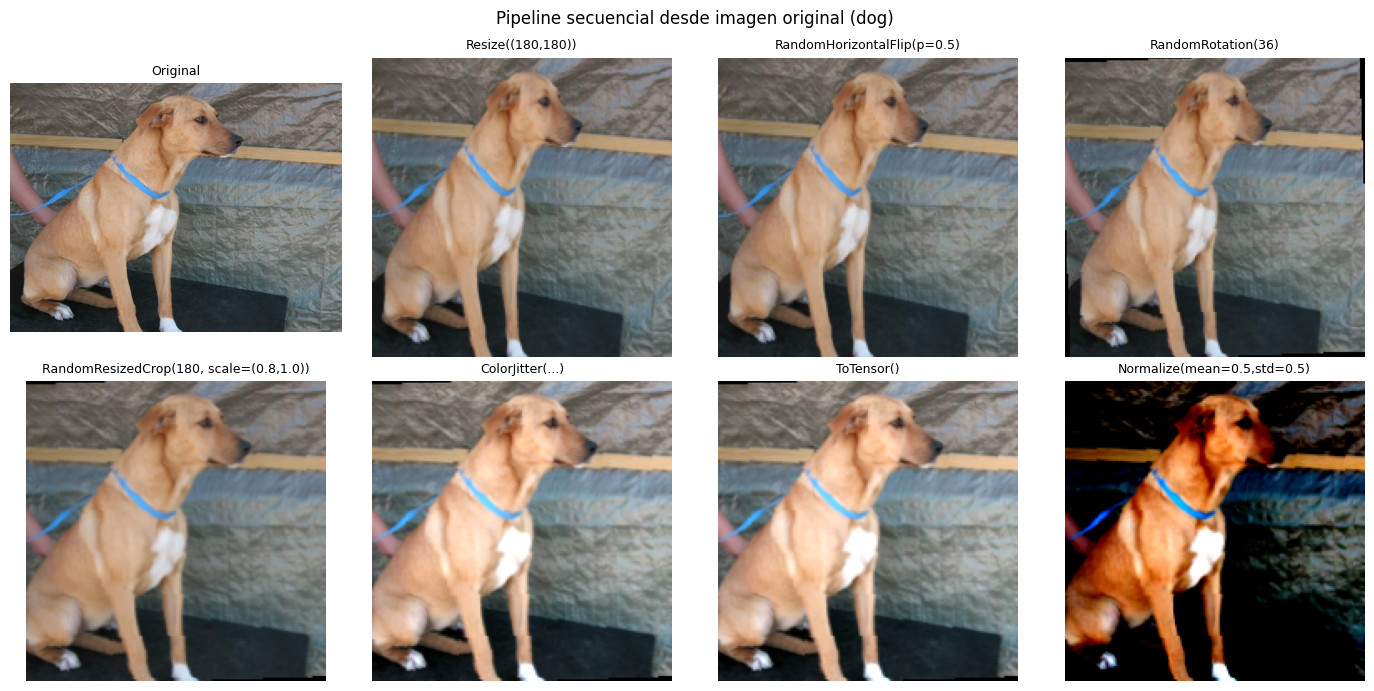

In [ ]:
def describe_compose(name, compose_obj):
    print(f'\n{name}')
    for i, t in enumerate(compose_obj.transforms, 1):
        print(f'  {i}. {t}')


def to_numpy_image(x):
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
        arr = np.transpose(arr, (1, 2, 0))
        return np.clip(arr, 0, 1)
    return np.array(x)


# Imagen fija para visualizacion
img_path = str(base_dir / 'train' / 'dog' / '445.jpg')
if not Path(img_path).exists():
    raise FileNotFoundError(f'No se encontro la imagen fija: {img_path}')
class_name = 'dog'

print(f'Imagen fija: {img_path}')
print(f'Clase: {class_name}')
print('Visualizacion secuencial: inicia en la ORIGINAL y aplica el pipeline completo en orden.')

describe_compose('Transformaciones Experimento A (sin augmentation):', plain_transform)
describe_compose('Transformaciones usadas para visualizacion:', show_aug_transform)

# Pipeline completo para visualizar (mismo orden del entrenamiento con augmentation)
full_aug_pipeline = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(36),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])
describe_compose('Pipeline completo de augmentation (train):', full_aug_pipeline)

img_pil = Image.open(img_path).convert('RGB')

# Mostrar aplicacion acumulativa paso a paso desde la ORIGINAL
viz_steps = [('Original', lambda x: x)] + [
    ('Resize((180,180))', transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))),
    ('RandomHorizontalFlip(p=0.5)', transforms.RandomHorizontalFlip(p=0.5)),
    ('RandomRotation(36)', transforms.RandomRotation(36)),
    ('RandomResizedCrop(180, scale=(0.8,1.0))', transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0))),
    ('ColorJitter(...)', transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)),
    ('ToTensor()', transforms.ToTensor()),
    ('Normalize(mean=0.5,std=0.5)', transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))),
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
current = img_pil
for ax, (name, t) in zip(axes.flat, viz_steps):
    current = t(current)
    ax.imshow(to_numpy_image(current))
    ax.axis('off')
    ax.set_title(name, fontsize=9)

plt.suptitle(f'Pipeline secuencial desde imagen original ({class_name})')
plt.tight_layout()
plt.show()

## Detalle de transformaciones de imagen

### Experimento A: sin data augmentation
1. `Resize((180, 180))`: unifica dimensiones para batching estable.
2. `ToTensor()`: convierte a tensor.
3. `Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))`: centra y escala a rango aprox. [-1, 1].

### Experimento B: con data augmentation (solo train)
1. `RandomHorizontalFlip(p=0.5)`:
- 50% de probabilidad de reflejo horizontal.
- Invariancia izquierda/derecha.

2. `RandomRotation(36)`:
- Rotacion aleatoria en rango aproximado [-36, +36] grados.
- Equivalente a 0.1 de vuelta completa del ejemplo del PDF.

3. `RandomResizedCrop(180, scale=(0.8, 1.0))`:
- Recorte aleatorio de 80% a 100% del area.
- Luego resize a 180x180.
- Simula zoom y pequenas traslaciones.

4. `ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)`:
- Perturbaciones suaves de color/iluminacion.
- Robustez ante condiciones de captura.

5. `ToTensor()` + `Normalize(...)`:
- Mismo esquema numerico del experimento A.

Nota clave: validacion y test usan pipeline determinista (sin transformaciones aleatorias).

Experimento A: SIN data augmentation
Epoch 01/50 | train_loss=0.69414 | val_loss=0.69173 | train_acc=0.50400 | val_acc=0.55400
Epoch 02/50 | train_loss=0.66769 | val_loss=0.62160 | train_acc=0.59600 | val_acc=0.63600
Epoch 03/50 | train_loss=0.63061 | val_loss=0.59456 | train_acc=0.64150 | val_acc=0.68200
Epoch 04/50 | train_loss=0.58753 | val_loss=0.55036 | train_acc=0.68800 | val_acc=0.72800
Epoch 05/50 | train_loss=0.55215 | val_loss=0.55543 | train_acc=0.71300 | val_acc=0.71200
Epoch 06/50 | train_loss=0.51109 | val_loss=0.49891 | train_acc=0.74950 | val_acc=0.76800
Epoch 07/50 | train_loss=0.48422 | val_loss=0.48253 | train_acc=0.76650 | val_acc=0.76600
Epoch 08/50 | train_loss=0.44845 | val_loss=0.50174 | train_acc=0.78200 | val_acc=0.74600
Epoch 09/50 | train_loss=0.42817 | val_loss=0.49502 | train_acc=0.79900 | val_acc=0.76600
Epoch 10/50 | train_loss=0.40039 | val_loss=0.48247 | train_acc=0.81400 | val_acc=0.77900
Epoch 11/50 | train_loss=0.36252 | val_loss=0.47921 | train_acc

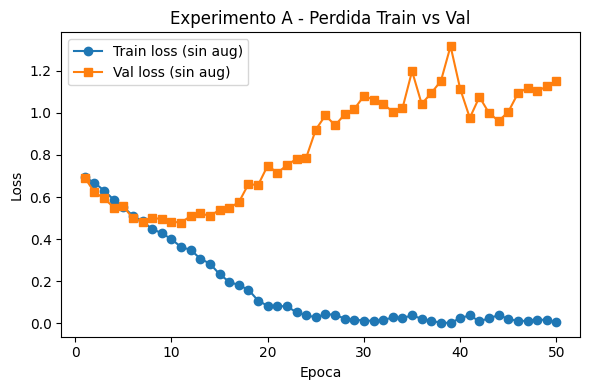

In [59]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 11 * 11, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze(1)


def run_epoch_binary(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)

    total_loss, total_correct, total_samples = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device)
        y = y.float().to(device)

        if training:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if training:
            loss.backward()
            optimizer.step()

        preds = (torch.sigmoid(logits) >= 0.5).long()
        total_loss += loss.item() * x.size(0)
        total_correct += (preds == y.long()).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


def train_model(train_loader, val_loader, epochs=EPOCHS, lr=3e-4):
    model = SmallCNN(num_classes=2).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch_binary(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch_binary(model, val_loader, criterion, optimizer=None)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        print(
            f'Epoch {epoch:02d}/{epochs} | '
            f'train_loss={tr_loss:.5f} | val_loss={va_loss:.5f} | '
            f'train_acc={tr_acc:.5f} | val_acc={va_acc:.5f}'
        )

    return model, history

print('Experimento A: SIN data augmentation')
model_plain, hist_plain = train_model(train_plain_loader, val_loader, epochs=EPOCHS)

criterion = nn.BCEWithLogitsLoss()
plain_test_loss, plain_test_acc = run_epoch_binary(model_plain, test_loader, criterion, optimizer=None)
print(f'Test acc (sin augmentation): {plain_test_acc:.5f}')

# Grafica de perdida para Experimento A
epochs_a = range(1, len(hist_plain['train_loss']) + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs_a, hist_plain['train_loss'], 'o-', label='Train loss (sin aug)')
plt.plot(epochs_a, hist_plain['val_loss'], 's-', label='Val loss (sin aug)')
plt.title('Experimento A - Perdida Train vs Val')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Experimento B: CON data augmentation
Epoch 01/50 | train_loss=0.69345 | val_loss=0.69116 | train_acc=0.51800 | val_acc=0.56800
Epoch 02/50 | train_loss=0.68148 | val_loss=0.67055 | train_acc=0.56450 | val_acc=0.58600
Epoch 03/50 | train_loss=0.67342 | val_loss=0.66071 | train_acc=0.58250 | val_acc=0.57700
Epoch 04/50 | train_loss=0.64693 | val_loss=0.61275 | train_acc=0.62050 | val_acc=0.65600
Epoch 05/50 | train_loss=0.62785 | val_loss=0.60838 | train_acc=0.64750 | val_acc=0.66400
Epoch 06/50 | train_loss=0.61507 | val_loss=0.59655 | train_acc=0.66800 | val_acc=0.67700
Epoch 07/50 | train_loss=0.60169 | val_loss=0.55832 | train_acc=0.67600 | val_acc=0.71200
Epoch 08/50 | train_loss=0.58835 | val_loss=0.56888 | train_acc=0.68450 | val_acc=0.69500
Epoch 09/50 | train_loss=0.58682 | val_loss=0.54783 | train_acc=0.68550 | val_acc=0.72700
Epoch 10/50 | train_loss=0.57227 | val_loss=0.52945 | train_acc=0.70050 | val_acc=0.73300
Epoch 11/50 | train_loss=0.55115 | val_loss=0.53306 | train_acc

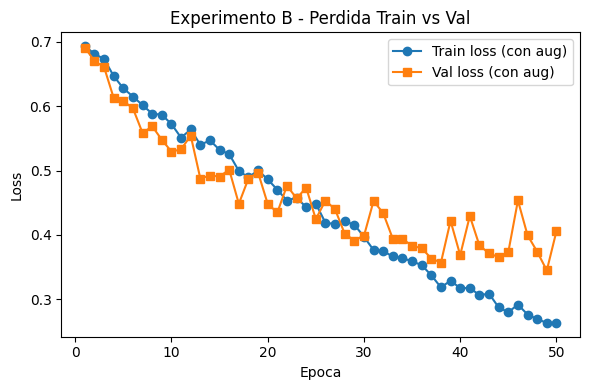

In [60]:
aug_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(36),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

train_aug = datasets.ImageFolder(base_dir / 'train', transform=aug_transform)
train_aug_loader = DataLoader(
    train_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print('Experimento B: CON data augmentation')
model_aug, hist_aug = train_model(train_aug_loader, val_loader, epochs=EPOCHS)

aug_test_loss, aug_test_acc = run_epoch_binary(model_aug, test_loader, criterion, optimizer=None)
print(f'Test acc (con augmentation): {aug_test_acc:.5f}')

# Grafica de perdida para Experimento B
epochs_b = range(1, len(hist_aug['train_loss']) + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs_b, hist_aug['train_loss'], 'o-', label='Train loss (con aug)')
plt.plot(epochs_b, hist_aug['val_loss'], 's-', label='Val loss (con aug)')
plt.title('Experimento B - Perdida Train vs Val')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()